In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!unzip /content/drive/MyDrive/CV/preprocessed_photos.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/preprocessed_photos/Zr64izKEIQAfxQKHO8MJDg.jpg  
  inflating: /content/preprocessed_photos/Zr6kLXlbtDZspEKzg_PCfw.jpg  
  inflating: /content/preprocessed_photos/zR6kpZCZ0M6T9PBaHicAAw.jpg  
  inflating: /content/preprocessed_photos/ZR6u23NGelTwZHEJd0ScAw.jpg  
  inflating: /content/preprocessed_photos/zR7cQ5vbBfbhFDeeRF1xGA.jpg  
  inflating: /content/preprocessed_photos/zr7E1J9b8HD1gxgbJ3TIQQ.jpg  
  inflating: /content/preprocessed_photos/ZR82ztyRpeJ2fIsB2nrIBw.jpg  
  inflating: /content/preprocessed_photos/Zr8qD0XvdgKV3Es-W2AdBg.jpg  
  inflating: /content/preprocessed_photos/ZR9T6khwqWNx0xqZgoTLXw.jpg  
  inflating: /content/preprocessed_photos/ZrA3QZ2Cd1nYsHJSt5UjUQ.jpg  
  inflating: /content/preprocessed_photos/zrADJQbbIJqCu0HxxLiHyg.jpg  
  inflating: /content/preprocessed_photos/zRAHBjj2U9zpfU_JEQYWpA.jpg  
  inflating: /content/preprocessed_photos/zRAnqSQ-dT3ClMRhOIU8kw.jpg  
  inflating: /content/prep

In [ ]:
import torch
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


from torchvision.transforms.functional import to_pil_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [ ]:
# Load datasets
df_train = pd.read_csv('/content/drive/MyDrive/CV/train_data.csv')
df_test = pd.read_csv('/content/drive/MyDrive/CV/test_data.csv')

# Sample train data for quicker training (optional)
df_train_sampled = df_train.sample(n=5000, random_state=42).reset_index(drop=True)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None, root_dir='/content'):
        self.data = dataframe
        self.transform = transform
        self.root_dir = root_dir

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = f"{self.root_dir}/{self.data.loc[idx, 'preprocessed_path']}"
        label = int(self.data.loc[idx, 'label_encoded'])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Create datasets and dataloaders
train_dataset = CustomImageDataset(df_train_sampled, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = CustomImageDataset(df_test, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# EfficientNet Model 1 (Unfreeze Layers)
model1 = models.efficientnet_b0(pretrained=True)

# Freeze all params first
for param in model1.parameters():
    param.requires_grad = False

# Unfreeze last 2 layers of features
for param in model1.features[-10:].parameters():
    param.requires_grad = True

model1.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model1.classifier[1].in_features, 8)
)
model1 = model1.to(device)

In [ ]:
# EfficientNet Model 2 (Adding Layers)
model2 = models.efficientnet_b0(pretrained=True)

# Freeze feature extractor params
for param in model2.features.parameters():
    param.requires_grad = False

model2.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model2.classifier[1].in_features, 512),
    nn.ReLU(),
    nn.Linear(512, 8)
)
model2 = model2.to(device)

In [ ]:
def train_model(model, train_loader, test_loader, epochs=10, patience=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total, correct, running_loss = 0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training", leave=False)
        for imgs, labels in loop:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=running_loss / (total / labels.size(0)), accuracy=correct / total)

        train_acc = correct / total
        train_loss = running_loss / (total / labels.size(0))

        # Evaluate on test set
        model.eval()
        total_test, correct_test, val_loss = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct_test += (preds == labels).sum().item()
                total_test += labels.size(0)
        test_acc = correct_test / total_test
        val_loss /= len(test_loader)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {test_acc:.4f}")

        # Early Stopping Logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"Early stopping patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    if best_model_state:
        model.load_state_dict(best_model_state)
        print("Best model restored.")


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import numpy as np
import torch.nn.functional as F

def evaluate_model(model, dataloader, num_classes=5):
    model.eval()
    total, correct = 0, 0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        loop = tqdm(dataloader, desc="Evaluating", leave=False)
        for imgs, labels in loop:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            loop.set_postfix(accuracy=100*correct/total)

    acc = 100 * correct / total
    print(f"Evaluation Accuracy: {acc:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

    # ROC AUC per class
    all_labels_onehot = np.eye(num_classes)[all_labels]  # One-hot encode labels
    all_probs = np.array(all_probs)

    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(all_labels_onehot[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

    plt.plot([0,1], [0,1], 'k--')  # Diagonal
    plt.title("ROC Curve per Class")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()

In [ ]:
def show_predictions(model, dataset, n=5):
    model.eval()
    for i in range(n):
        image, label = dataset[i]
        input_tensor = image.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_tensor)
        pred = torch.argmax(output, dim=1).item()

        plt.imshow(image.permute(1, 2, 0))
        plt.title(f"True: {label} | Pred: {pred}")
        plt.axis('off')
        plt.show()

Training Model 1 (Unfreeze Layers)


Epoch 1/10 | Train Loss: 0.0899 | Train Acc: 0.8876 | Val Loss: 0.2717 | Val Acc: 0.9047


Epoch 2/10 | Train Loss: 0.0484 | Train Acc: 0.9356 | Val Loss: 0.2402 | Val Acc: 0.9201


Epoch 3/10 | Train Loss: 0.0372 | Train Acc: 0.9518 | Val Loss: 0.3654 | Val Acc: 0.9094
Early stopping patience: 1/3


Epoch 4/10 | Train Loss: 0.0260 | Train Acc: 0.9656 | Val Loss: 0.2394 | Val Acc: 0.9348


Epoch 5/10 | Train Loss: 0.0212 | Train Acc: 0.9714 | Val Loss: 0.2601 | Val Acc: 0.9270
Early stopping patience: 1/3


Epoch 6/10 | Train Loss: 0.0168 | Train Acc: 0.9762 | Val Loss: 0.3041 | Val Acc: 0.9141
Early stopping patience: 2/3


Epoch 7/10 | Train Loss: 0.0193 | Train Acc: 0.9738 | Val Loss: 0.3151 | Val Acc: 0.9260
Early stopping patience: 3/3
Early stopping triggered.
Best model restored.

Evaluating Model 1 on Train Set


Evaluation Accuracy: 99.32%


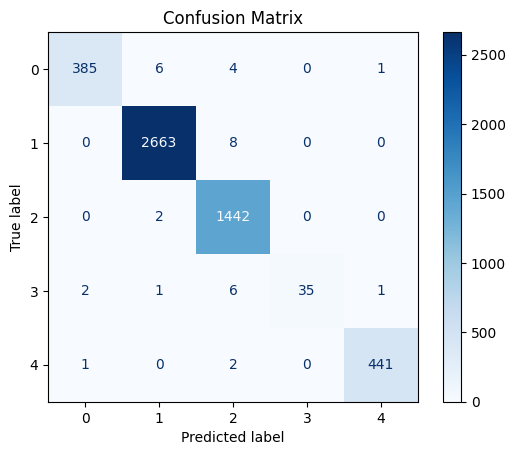

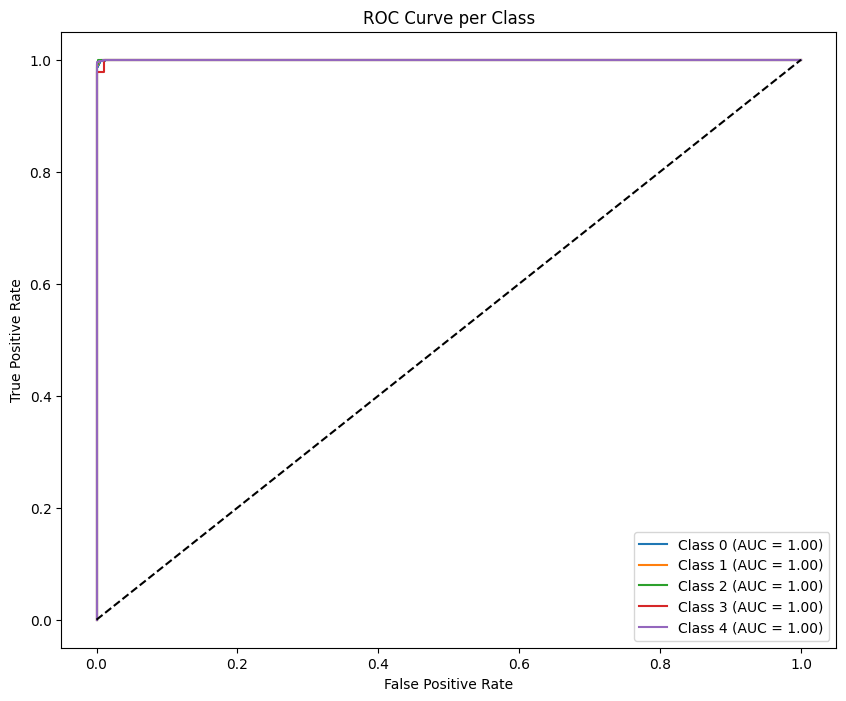


Evaluating Model 1 on Test Set


Evaluation Accuracy: 92.60%


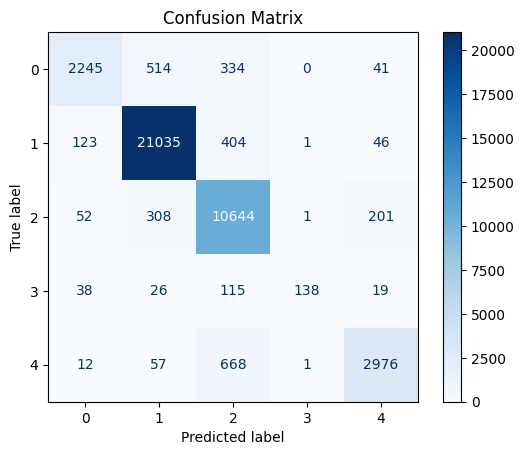

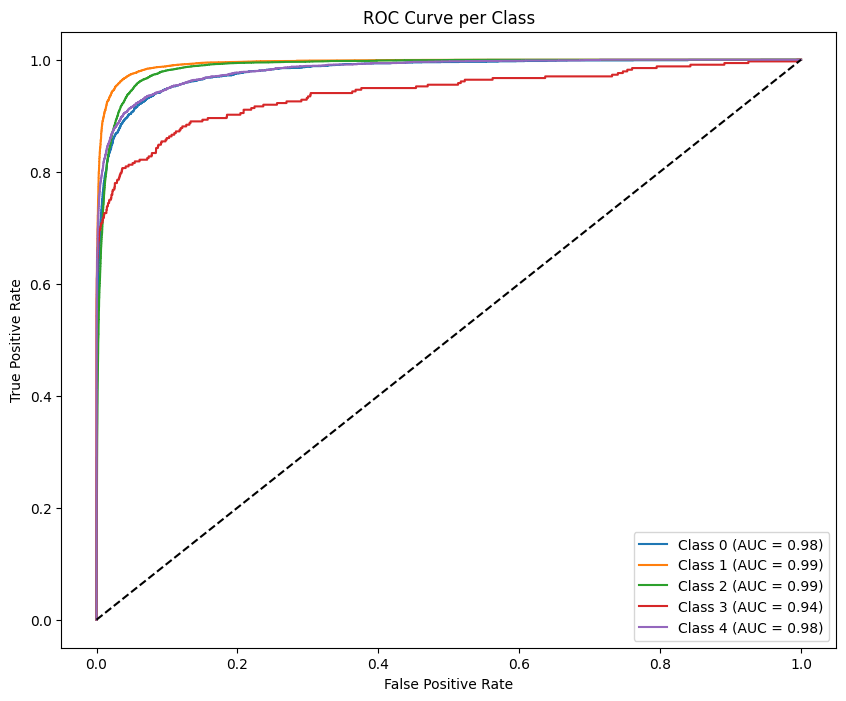


Sample Predictions from Model 1 (Test Set)


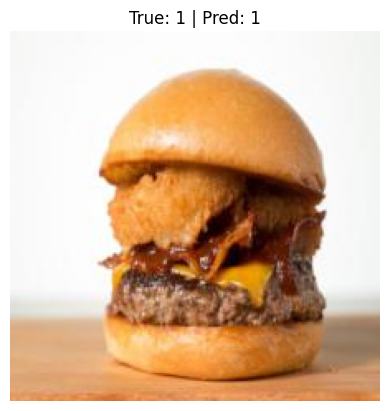

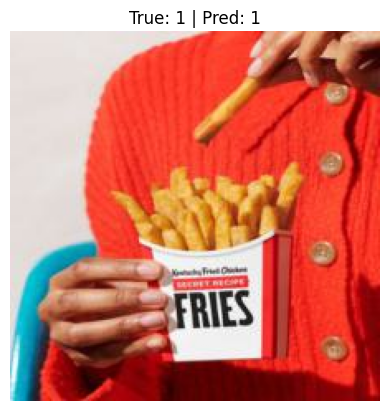

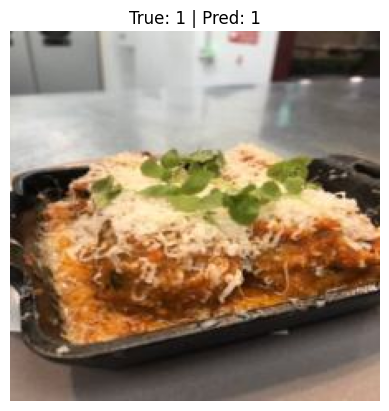

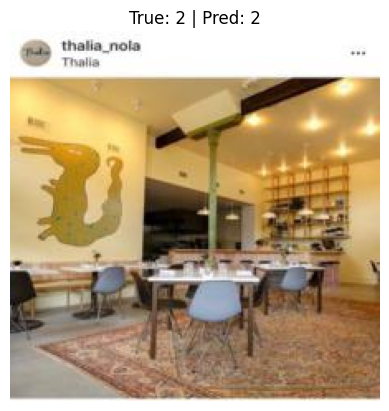

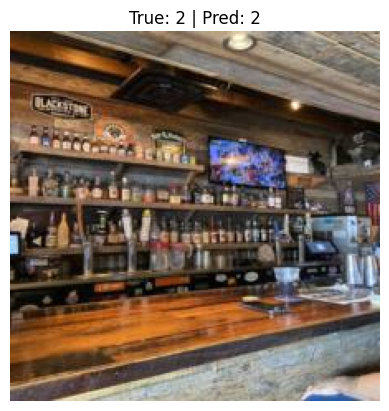

In [ ]:
# Model 1
print("Training Model 1 (Unfreeze Layers)")
train_model(model1, train_loader, test_loader)

print("\nEvaluating Model 1 on Train Set")
evaluate_model(model1, train_loader)

print("\nEvaluating Model 1 on Test Set")
evaluate_model(model1, test_loader)

print("\nSample Predictions from Model 1 (Test Set)")
show_predictions(model1, test_dataset)

Training Model 2 (Added Layers)


Epoch 1/10 | Train Loss: 0.0745 | Train Acc: 0.8998 | Val Loss: 0.1930 | Val Acc: 0.9349


Epoch 2/10 | Train Loss: 0.0559 | Train Acc: 0.9212 | Val Loss: 0.1839 | Val Acc: 0.9366


Epoch 3/10 | Train Loss: 0.0495 | Train Acc: 0.9300 | Val Loss: 0.1780 | Val Acc: 0.9394


Epoch 4/10 | Train Loss: 0.0449 | Train Acc: 0.9371 | Val Loss: 0.1773 | Val Acc: 0.9404


Epoch 5/10 | Train Loss: 0.0411 | Train Acc: 0.9380 | Val Loss: 0.1817 | Val Acc: 0.9393
Early stopping patience: 1/3


Epoch 6/10 | Train Loss: 0.0384 | Train Acc: 0.9441 | Val Loss: 0.1797 | Val Acc: 0.9407
Early stopping patience: 2/3


Epoch 7/10 | Train Loss: 0.0344 | Train Acc: 0.9523 | Val Loss: 0.1812 | Val Acc: 0.9409
Early stopping patience: 3/3
Early stopping triggered.
Best model restored.

Evaluating Model 2 on Train Set


Evaluation Accuracy: 98.66%


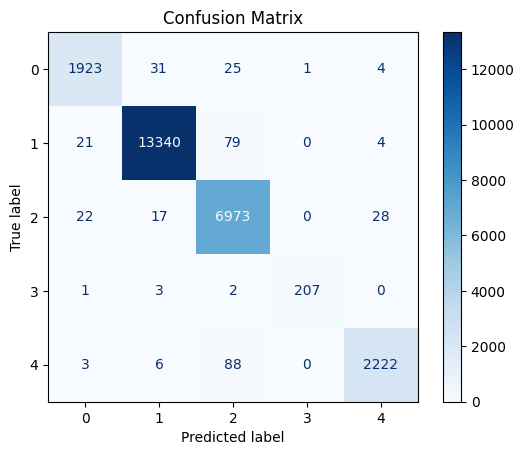

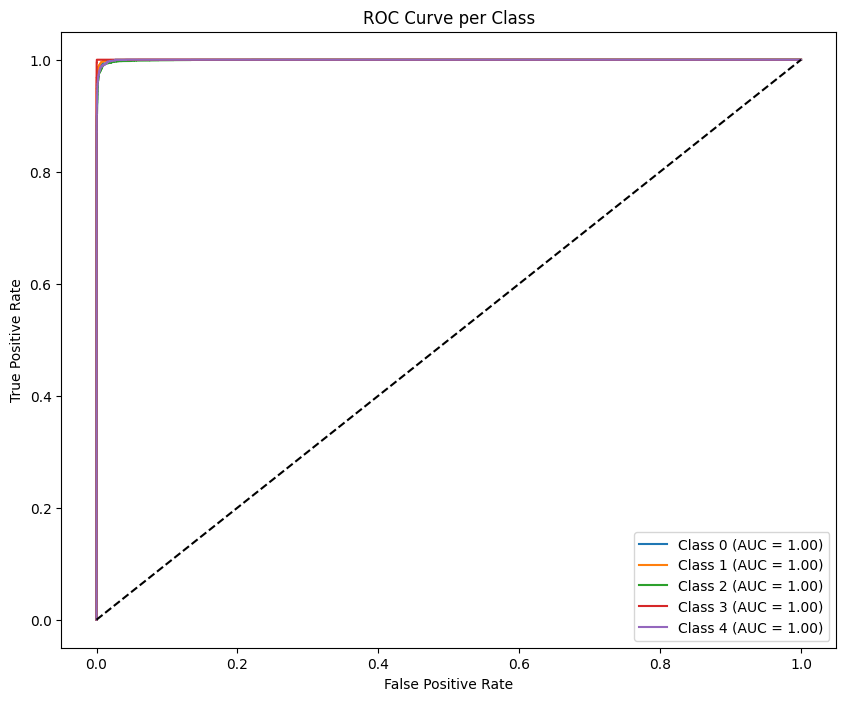


Evaluating Model 2 on Test Set


Evaluation Accuracy: 94.09%


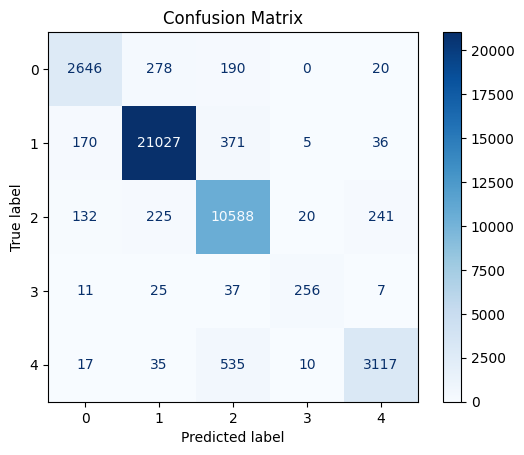

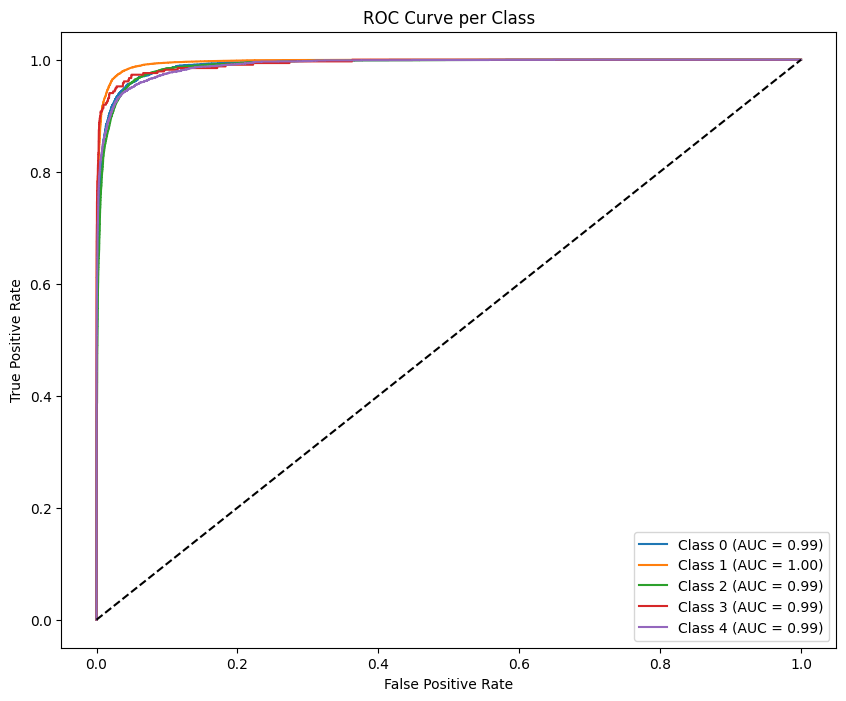


Sample Predictions from Model 2 (Test Set)


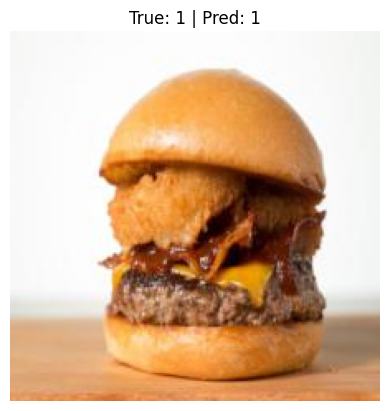

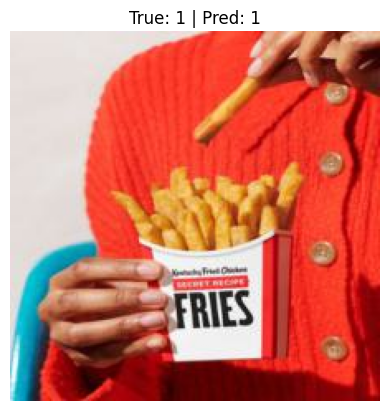

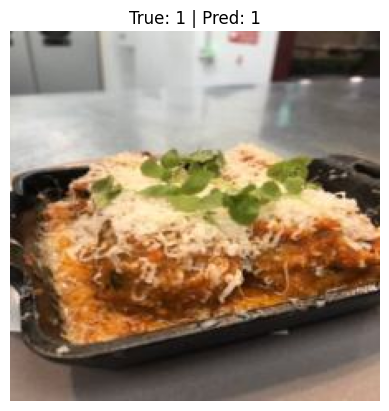

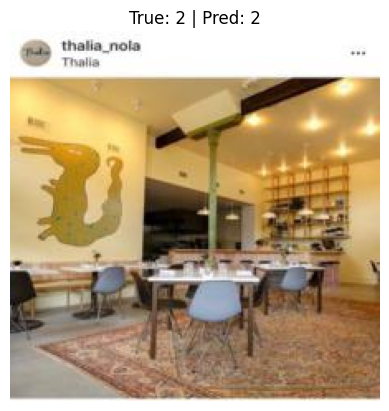

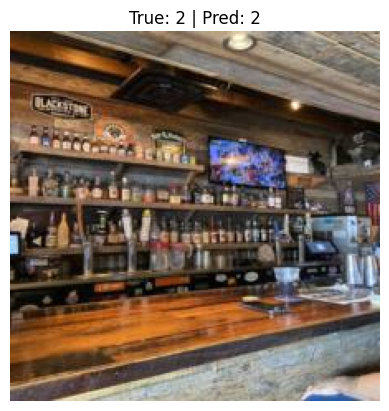

In [ ]:
print("Training Model 2 (Added Layers)")
train_model(model2, train_loader, test_loader)

print("\nEvaluating Model 2 on Train Set")
evaluate_model(model2, train_loader)

print("\nEvaluating Model 2 on Test Set")
evaluate_model(model2, test_loader)

print("\nSample Predictions from Model 2 (Test Set)")
show_predictions(model2, test_dataset)